## 1. Environment Setup

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization, Input
)
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python version :", sys.version.split()[0])
print("TensorFlow     :", tf.__version__)
print("Keras          :", tf.keras.__version__)
print("GPU Available  :", tf.config.list_physical_devices('GPU'))

# NOTE: Colab's default runtime ships a recent TensorFlow (Keras 3-based).
# Do not manually downgrade TensorFlow - it may break GPU support on Colab.


Python version : 3.12.13
TensorFlow     : 2.20.0
Keras          : 3.13.2
GPU Available  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Download & Configuration



In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ⚠️ Apna actual Drive path yahan set karo (jahan dataset upload ki hai)
DATASET_DIR = "/content/drive/MyDrive/dataset"

!ls "{DATASET_DIR}"

Mounted at /content/drive
Test  Train  Validation


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATASET_DIR = "/content/drive/MyDrive/dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
VAL_DIR   = os.path.join(DATASET_DIR, "Validation")
TEST_DIR  = os.path.join(DATASET_DIR, "Test")

MODELS_DIR  = "/content/models"
RESULTS_DIR = "/content/results"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASSES = ["WithMask", "WithoutMask"]
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 25

print("Train dir     :", TRAIN_DIR)
print("Validation dir:", VAL_DIR)
print("Test dir      :", TEST_DIR)


Train dir     : /content/drive/MyDrive/dataset/Train
Validation dir: /content/drive/MyDrive/dataset/Validation
Test dir      : /content/drive/MyDrive/dataset/Test


## 3. Exploratory Data Analysis (EDA)

Is section mein hum dataset ko detail se samajhte hain:
- Class-wise image counts (train/val/test)
- Class balance visualization
- Sample images per class
- Image dimension / aspect-ratio distribution
- Average pixel intensity & color channel analysis
- Corrupt/duplicate image check


### 3.1 Class Distribution Across Splits

In [5]:
def count_images(split_dir):
    counts = {}
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.exists(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                                if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        else:
            counts[cls] = 0
    return counts

split_counts = {
    "Train": count_images(TRAIN_DIR),
    "Validation": count_images(VAL_DIR),
    "Test": count_images(TEST_DIR),
}

df_counts = pd.DataFrame(split_counts).T
df_counts["Total"] = df_counts.sum(axis=1)
df_counts.loc["Total"] = df_counts.sum()
df_counts


,WithMask,WithoutMask,Total
Train,5000,5000,10000
Validation,400,400,800
Test,483,509,992
Total,5883,5909,11792


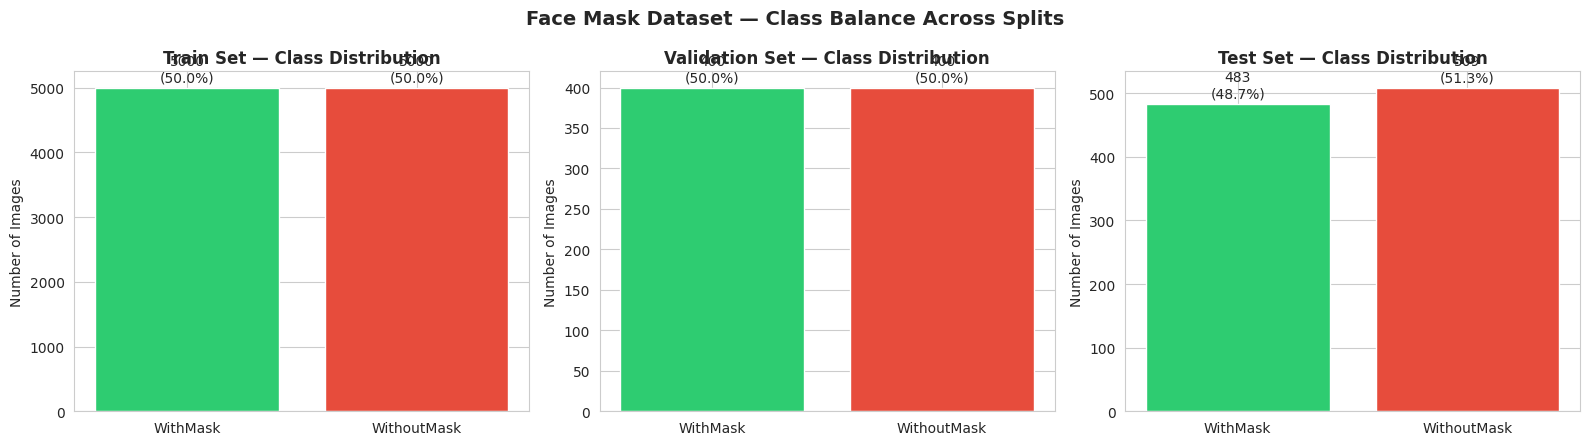

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = ["#2ecc71", "#e74c3c"]

for ax, split in zip(axes, ["Train", "Validation", "Test"]):
    counts = split_counts[split]
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f"{split} Set — Class Distribution", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Images")
    total = sum(counts.values())
    for bar, v in zip(bars, counts.values()):
        pct = v / total * 100 if total else 0
        ax.text(bar.get_x() + bar.get_width()/2, v + max(counts.values())*0.02,
                 f"{v}\n({pct:.1f}%)", ha="center", fontsize=10)

plt.suptitle("Face Mask Dataset — Class Balance Across Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()


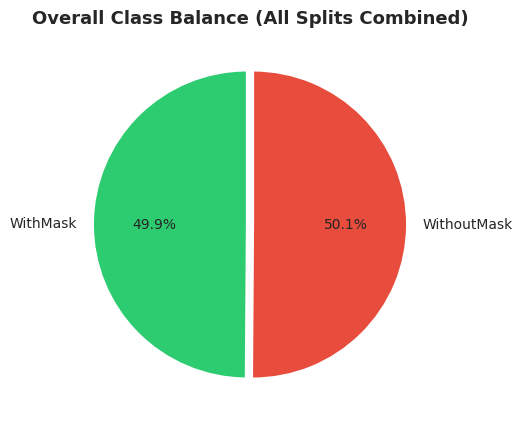

Class imbalance ratio: 1.00 : 1
Dataset is well balanced — no special class-weighting needed.


In [7]:
# Pie chart - overall class balance (combining all splits)
overall = df_counts.loc["Total", CLASSES]

plt.figure(figsize=(5, 5))
plt.pie(overall, labels=overall.index, autopct="%1.1f%%",
        colors=colors, startangle=90, explode=(0.02, 0.02),
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("Overall Class Balance (All Splits Combined)", fontsize=13, fontweight="bold")
plt.savefig(os.path.join(RESULTS_DIR, "overall_class_balance.png"), bbox_inches="tight")
plt.show()

imbalance_ratio = overall.max() / overall.min()
print(f"Class imbalance ratio: {imbalance_ratio:.2f} : 1")
if imbalance_ratio < 1.2:
    print("Dataset is well balanced — no special class-weighting needed.")
else:
    print("Mild imbalance detected — consider class_weight during training.")


### 3.2 Sample Images per Class

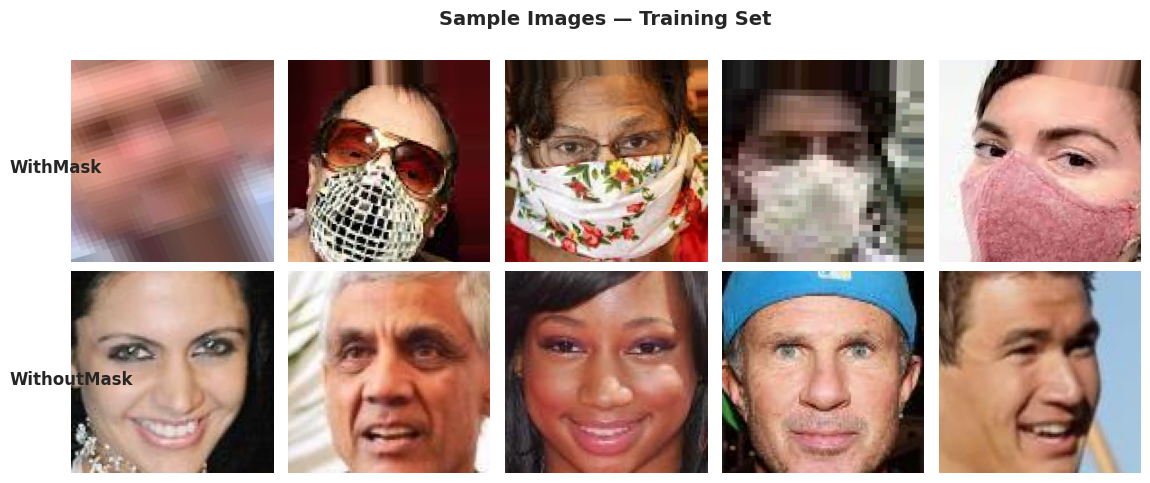

In [8]:
def plot_sample_images(split_dir, n_per_class=5):
    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(n_per_class * 2.2, 5))

    for row, cls in enumerate(CLASSES):
        cls_path = os.path.join(split_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        sample = random.sample(images, min(n_per_class, len(images)))

        for col, img_name in enumerate(sample):
            img = Image.open(os.path.join(cls_path, img_name))
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
        axes[row, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold", x=-0.3, y=0.4)

    plt.suptitle("Sample Images — Training Set", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "sample_images.png"), bbox_inches="tight")
    plt.show()

plot_sample_images(TRAIN_DIR)


### 3.3 Image Dimension & Aspect Ratio Analysis

In [9]:
def sample_image_dimensions(split_dir, n_samples=300):
    records = []
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        sample = random.sample(images, min(n_samples, len(images)))
        for img_name in sample:
            try:
                with Image.open(os.path.join(cls_path, img_name)) as img:
                    w, h = img.size
                    records.append({"class": cls, "width": w, "height": h,
                                     "aspect_ratio": round(w / h, 2)})
            except Exception:
                continue
    return pd.DataFrame(records)

dim_df = sample_image_dimensions(TRAIN_DIR)
dim_df.describe()


,width,height,aspect_ratio
count,600.000000,600.000000,600.0
mean,153.223333,153.223333,1.0
std,62.427067,62.427067,0.0
min,27.000000,27.000000,1.0
25%,102.000000,102.000000,1.0
50%,115.000000,115.000000,1.0
75%,224.000000,224.000000,1.0
max,224.000000,224.000000,1.0


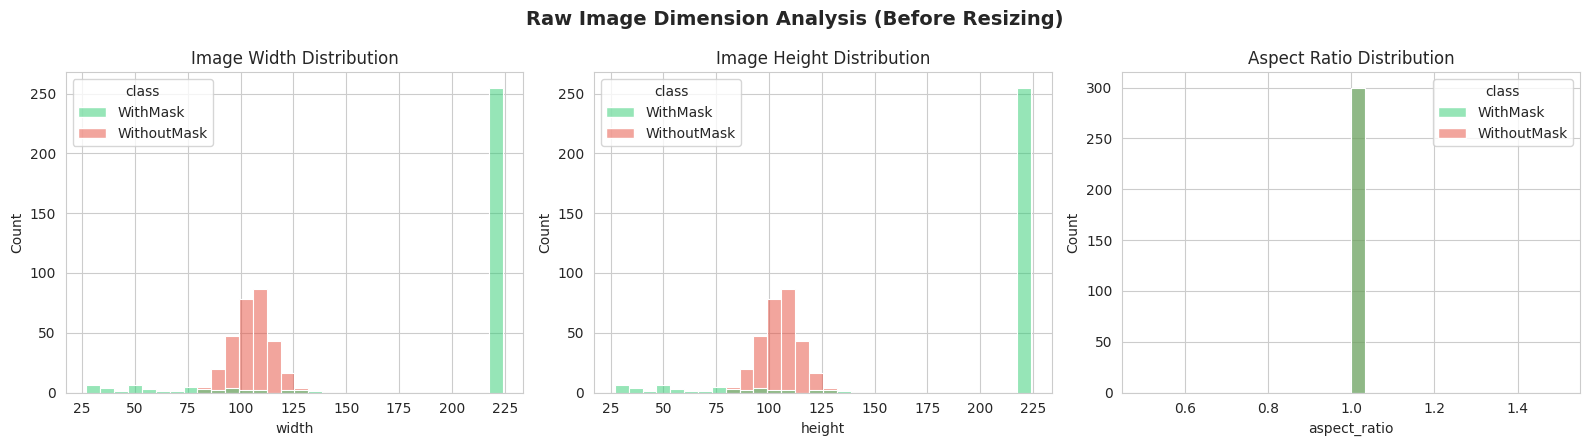

All images will be resized to (128, 128) before training.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(data=dim_df, x="width", hue="class", bins=30, ax=axes[0], palette=colors)
axes[0].set_title("Image Width Distribution")

sns.histplot(data=dim_df, x="height", hue="class", bins=30, ax=axes[1], palette=colors)
axes[1].set_title("Image Height Distribution")

sns.histplot(data=dim_df, x="aspect_ratio", hue="class", bins=30, ax=axes[2], palette=colors)
axes[2].set_title("Aspect Ratio Distribution")

plt.suptitle("Raw Image Dimension Analysis (Before Resizing)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dimension_analysis.png"), bbox_inches="tight")
plt.show()

print(f"All images will be resized to {IMG_SIZE} before training.")


### 3.4 Average Pixel Intensity & Color Channel Analysis

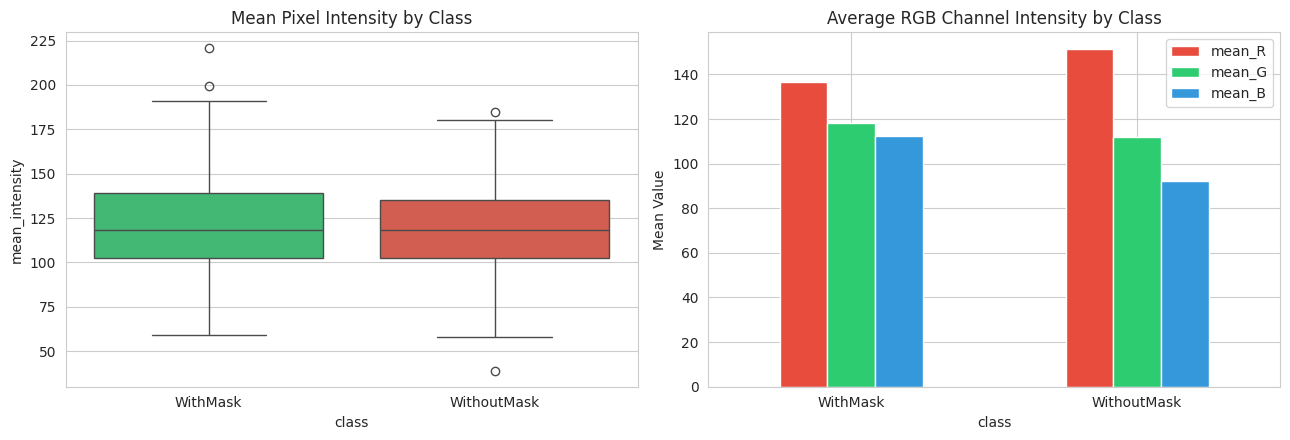

In [11]:
def analyze_pixel_intensity(split_dir, n_samples=150):
    records = []
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        sample = random.sample(images, min(n_samples, len(images)))
        for img_name in sample:
            img = cv2.imread(os.path.join(cls_path, img_name))
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            b, g, r = cv2.split(img)
            records.append({
                "class": cls,
                "mean_intensity": img.mean(),
                "mean_R": r.mean(), "mean_G": g.mean(), "mean_B": b.mean(),
            })
    return pd.DataFrame(records)

pixel_df = analyze_pixel_intensity(TRAIN_DIR)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=pixel_df, x="class", y="mean_intensity", ax=axes[0], palette=colors)
axes[0].set_title("Mean Pixel Intensity by Class")

channel_means = pixel_df.groupby("class")[["mean_R", "mean_G", "mean_B"]].mean()
channel_means.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2ecc71", "#3498db"])
axes[1].set_title("Average RGB Channel Intensity by Class")
axes[1].set_ylabel("Mean Value")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pixel_intensity_analysis.png"), bbox_inches="tight")
plt.show()


### 3.5 Data Quality Check — Corrupt Image Scan

In [12]:
def scan_corrupt_images(split_dir):
    corrupt_files = []
    for cls in CLASSES:
        cls_path = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            fpath = os.path.join(cls_path, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception:
                corrupt_files.append(fpath)
    return corrupt_files

corrupt = scan_corrupt_images(TRAIN_DIR)
print(f"Corrupt/unreadable images found in Train set: {len(corrupt)}")
if corrupt:
    print(corrupt[:10])
else:
    print("No corrupt images detected. Dataset is clean.")


Corrupt/unreadable images found in Train set: 0
No corrupt images detected. Dataset is clean.


## 4. Data Preprocessing & Augmentation

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=True, seed=SEED,
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=False,
)

print("Class indices:", train_generator.class_indices)
print(f"Train samples: {train_generator.samples} | "
      f"Validation samples: {validation_generator.samples} | "
      f"Test samples: {test_generator.samples}")


Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Class indices: {'WithMask': 0, 'WithoutMask': 1}
Train samples: 10000 | Validation samples: 800 | Test samples: 992


### 4.1 Visualize Augmentation Effect

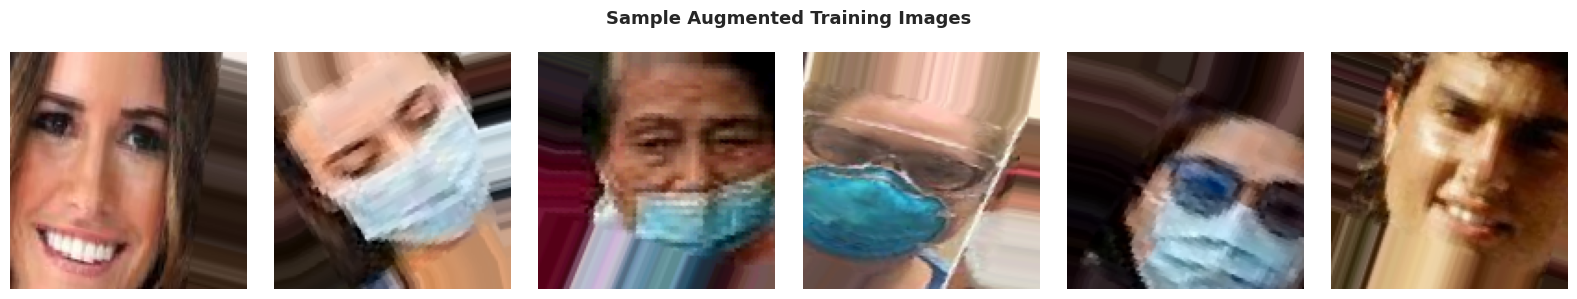

In [14]:
sample_batch, _ = next(train_generator)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i in range(6):
    axes[i].imshow(sample_batch[i])
    axes[i].axis("off")
plt.suptitle("Sample Augmented Training Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "augmentation_samples.png"), bbox_inches="tight")
plt.show()


## 5. Model Architectures

Three models are compared: a Custom CNN (built from scratch), and two transfer-learning models (MobileNetV2, ResNet50).

In [15]:
INPUT_SHAPE = (128, 128, 3)

def build_custom_cnn():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ], name="Custom_CNN")

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_mobilenetv2():
    base_model = MobileNetV2(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output, name="MobileNetV2_Transfer")
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_resnet50():
    base_model = ResNet50(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output, name="ResNet50_Transfer")
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


MODEL_BUILDERS = {
    "custom_cnn": build_custom_cnn,
    "mobilenetv2": build_mobilenetv2,
    "resnet50": build_resnet50,
}

# Quick parameter count comparison
param_summary = []
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    param_summary.append({
        "Model": name,
        "Total Params": f"{m.count_params():,}",
        "Trainable Params": f"{sum(tf.keras.backend.count_params(w) for w in m.trainable_weights):,}",
    })
    del m

pd.DataFrame(param_summary)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Model,Total Params,Trainable Params
0,custom_cnn,"4,601,409","4,600,449"
1,mobilenetv2,"2,422,081","164,097"
2,resnet50,"23,850,113","262,401"


## 6. Model Training

In [16]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(MODELS_DIR, f"{model_name}_best.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]


def train_model(model_name):
    print(f"\n{'='*70}\nTraining: {model_name}\n{'='*70}")

    model = MODEL_BUILDERS[model_name]()
    model.summary()

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_name),
        verbose=1,
    )

    final_path = os.path.join(MODELS_DIR, f"{model_name}_final.keras")
    model.save(final_path)
    print(f"Saved final model: {final_path}")

    with open(os.path.join(RESULTS_DIR, f"{model_name}_history.json"), "w") as f:
        json.dump(history.history, f, indent=2)

    return model, history


In [ ]:
trained_models = {}
histories = {}

for model_name in ["custom_cnn", "mobilenetv2", "resnet50"]:
    model, history = train_model(model_name)
    trained_models[model_name] = model
    histories[model_name] = history



Training: custom_cnn


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,601,409 (17.55 MB)

 Trainable params: 4,600,449 (17.55 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.4983 - loss: 0.7178
Epoch 1: val_accuracy improved from None to 0.54500, saving model to /content/models/resnet50_best.keras

Epoch 1: finished saving model to /content/models/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 332ms/step - accuracy: 0.5180 - loss: 0.7050 - val_accuracy: 0.5450 - val_loss: 0.6810 - learning_rate: 1.0000e-04
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5308 - loss: 0.6911
Epoch 2: val_accuracy improved from 0.54500 to 0.60750, saving model to /content/models/resnet50_best.keras

Epoch 2: finished saving model to /content/models/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 296ms/step - accuracy: 0.5443 - loss: 0.6856 - val_accuracy: 0.6075 - val_loss: 0.6713 - learning_rate: 1.0000e-04
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5762 - loss: 0.6715
Epoch 3: val_accuracy improved from 0.60750 to 0.61125, saving model to /content/mod

### 6.1 Training Curves — All Models Side-by-Side

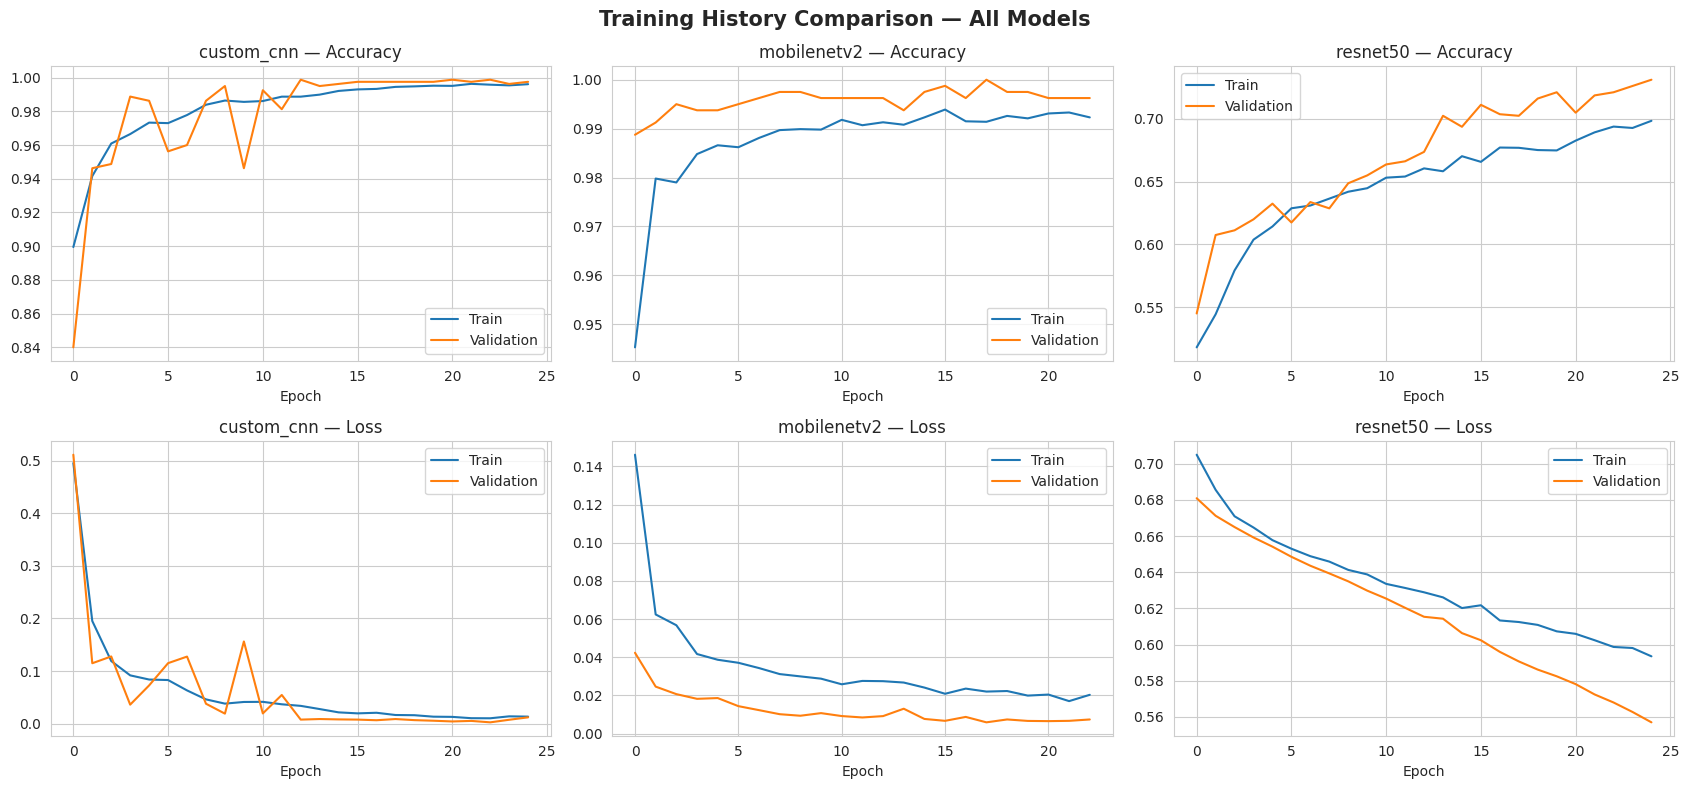

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for col, (name, history) in enumerate(histories.items()):
    axes[0, col].plot(history.history["accuracy"], label="Train")
    axes[0, col].plot(history.history["val_accuracy"], label="Validation")
    axes[0, col].set_title(f"{name} — Accuracy")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].legend()

    axes[1, col].plot(history.history["loss"], label="Train")
    axes[1, col].plot(history.history["val_loss"], label="Validation")
    axes[1, col].set_title(f"{name} — Loss")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].legend()

plt.suptitle("Training History Comparison — All Models", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "all_models_training_history.png"), bbox_inches="tight")
plt.show()


## 7. Detailed Model Evaluation & Comparison

Har model ko test set pe evaluate karte hain:
- Accuracy, Precision, Recall, F1-Score, AUC
- Confusion Matrix
- ROC Curve
- Classification Report
- Misclassified sample inspection
- Final side-by-side comparison chart


In [29]:
def evaluate_model(model, model_name, test_gen):
    test_gen.reset()
    y_true = test_gen.classes
    y_pred_probs = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_pred_probs >= 0.5).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    metrics["AUC"] = auc(fpr, tpr)

    return metrics, y_true, y_pred, y_pred_probs, fpr, tpr


all_results = {}
roc_data = {}

for name, model in trained_models.items():
    metrics, y_true, y_pred, y_pred_probs, fpr, tpr = evaluate_model(model, name, test_generator)
    all_results[name] = {"metrics": metrics, "y_true": y_true, "y_pred": y_pred,
                          "y_pred_probs": y_pred_probs}
    roc_data[name] = (fpr, tpr, metrics["AUC"])
    print(f"\n{name}: {metrics}")



custom_cnn: {'Model': 'custom_cnn', 'Accuracy': 0.998991935483871, 'Precision': 1.0, 'Recall': 0.9980353634577603, 'F1-Score': 0.9990167158308751, 'AUC': np.float64(0.9999918648590383)}

mobilenetv2: {'Model': 'mobilenetv2', 'Accuracy': 0.9939516129032258, 'Precision': 0.998019801980198, 'Recall': 0.9901768172888016, 'F1-Score': 0.9940828402366864, 'AUC': np.float64(0.9997356079187463)}

resnet50: {'Model': 'resnet50', 'Accuracy': 0.7631048387096774, 'Precision': 0.7329931972789115, 'Recall': 0.8467583497053045, 'F1-Score': 0.7857793983591613, 'AUC': np.float64(0.8645865111227715)}


### 7.1 Confusion Matrices — All Models

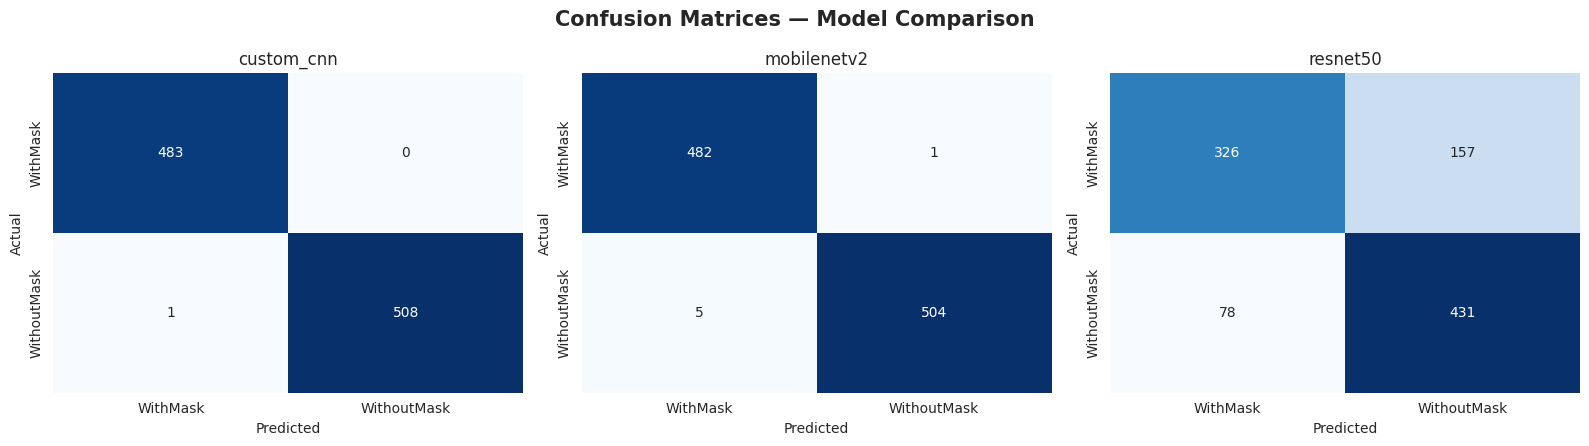

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, result) in zip(axes, all_results.items()):
    cm = confusion_matrix(result["y_true"], result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Model Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrices_comparison.png"), bbox_inches="tight")
plt.show()


### 7.2 ROC Curves — All Models Overlaid

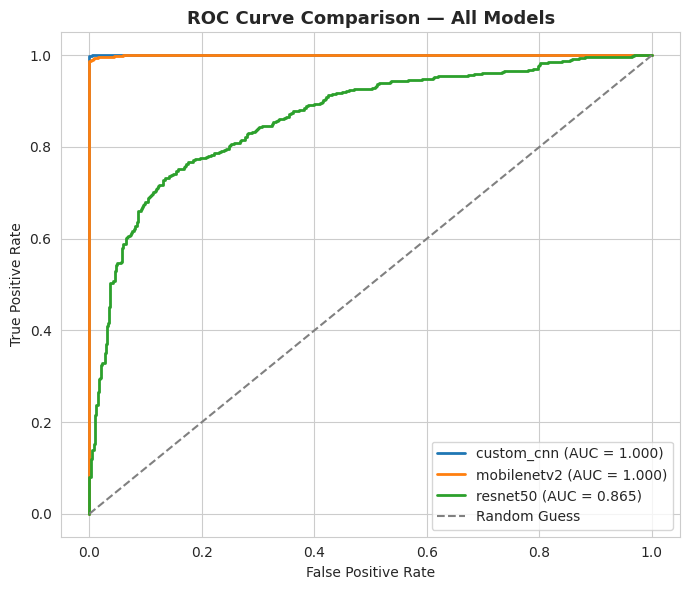

In [31]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curves_comparison.png"), bbox_inches="tight")
plt.show()


### 7.3 Classification Reports

In [32]:
for name, result in all_results.items():
    print(f"\n{'='*60}\n{name} — Classification Report\n{'='*60}")
    print(classification_report(result["y_true"], result["y_pred"], target_names=CLASSES))



custom_cnn — Classification Report
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992


mobilenetv2 — Classification Report
              precision    recall  f1-score   support

    WithMask       0.99      1.00      0.99       483
 WithoutMask       1.00      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992


resnet50 — Classification Report
              precision    recall  f1-score   support

    WithMask       0.81      0.67      0.74       483
 WithoutMask       0.73      0.85      0.79       509

    accuracy                           0.76       992
   macro avg       0.

### 7.4 Metric Comparison Table & Bar Chart

In [33]:
comparison_df = pd.DataFrame([r["metrics"] for r in all_results.values()]).set_index("Model")
comparison_df = comparison_df.round(4)
comparison_df.to_json(os.path.join(RESULTS_DIR, "model_comparison_report.json"), indent=2)
comparison_df.style.highlight_max(color="lightgreen", axis=0)


,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
custom_cnn,0.999000,1.000000,0.998000,0.999000,1.000000
mobilenetv2,0.994000,0.998000,0.990200,0.994100,0.999700
resnet50,0.763100,0.733000,0.846800,0.785800,0.864600


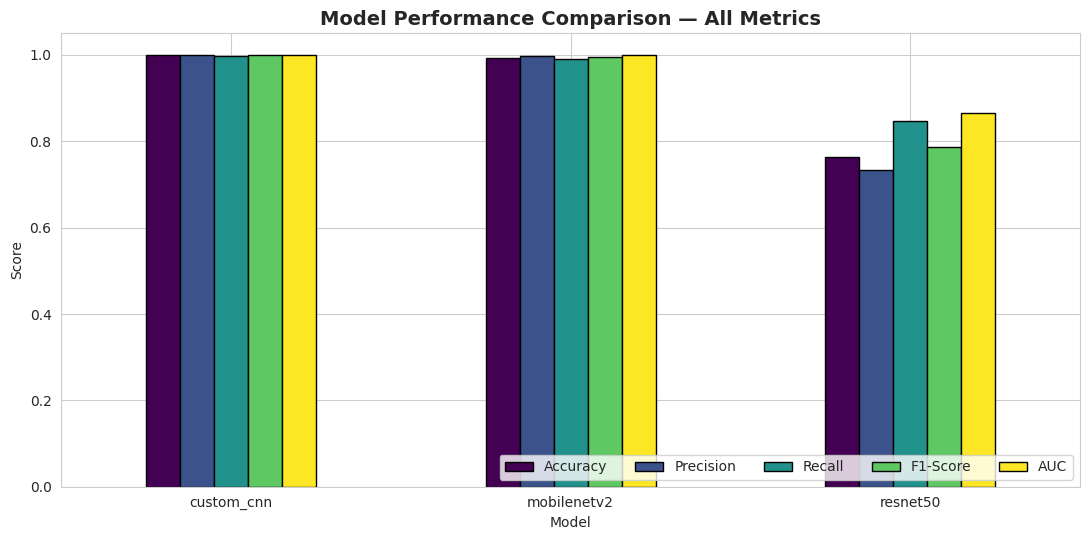


Best performing model on test accuracy: custom_cnn
Accuracy     0.999
Precision    1.000
Recall       0.998
F1-Score     0.999
AUC          1.000
Name: custom_cnn, dtype: float64


In [34]:
fig, ax = plt.subplots(figsize=(11, 5.5))
comparison_df.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="black")
ax.set_title("Model Performance Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_comparison_bar_chart.png"), bbox_inches="tight")
plt.show()

best_model_name = comparison_df["Accuracy"].idxmax()
print(f"\nBest performing model on test accuracy: {best_model_name}")
print(comparison_df.loc[best_model_name])


### 7.5 Misclassified Sample Inspection (Best Model)

Total misclassified samples (custom_cnn): 1 / 992


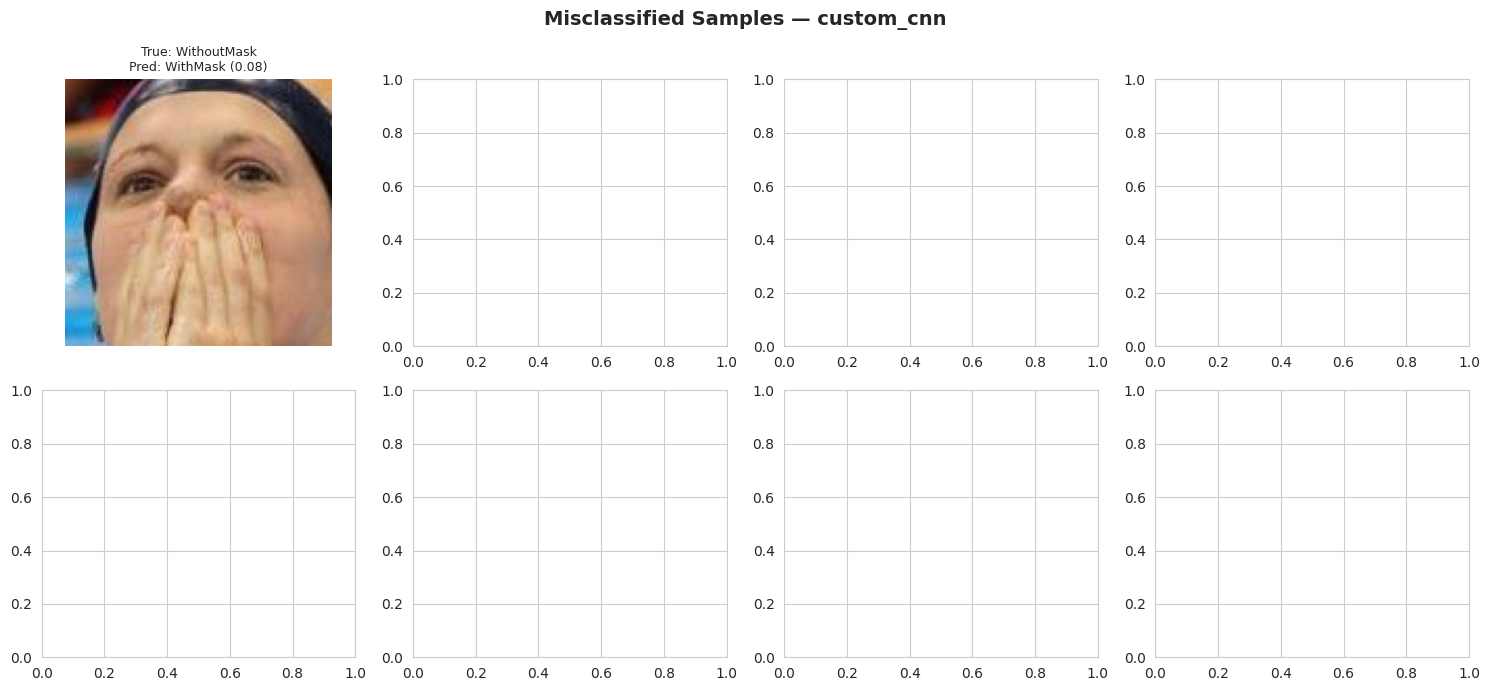

In [35]:
best_result = all_results[best_model_name]
mismatches = np.where(best_result["y_true"] != best_result["y_pred"])[0]
print(f"Total misclassified samples ({best_model_name}): {len(mismatches)} / {len(best_result['y_true'])}")

if len(mismatches) > 0:
    test_generator.reset()
    filepaths = test_generator.filepaths
    n_show = min(8, len(mismatches))
    sample_idx = np.random.choice(mismatches, n_show, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    for ax, idx in zip(axes.ravel(), sample_idx):
        img = Image.open(filepaths[idx])
        ax.imshow(img)
        true_label = CLASSES[best_result["y_true"][idx]]
        pred_label = CLASSES[best_result["y_pred"][idx]]
        conf = best_result["y_pred_probs"][idx]
        ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})", fontsize=9)
        ax.axis("off")

    plt.suptitle(f"Misclassified Samples — {best_model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "misclassified_samples.png"), bbox_inches="tight")
    plt.show()
else:
    print("No misclassifications found on the test set.")


## 8. Conclusion

Run the cell below for a final auto-generated summary of the experiment.

In [36]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(comparison_df.to_string())
print(f"\nBest Model: {best_model_name}")
print(f"Saved at  : {MODELS_DIR}/{best_model_name}_best.keras")
print("\nAll results, plots, and reports saved under:", RESULTS_DIR)


FINAL SUMMARY
             Accuracy  Precision  Recall  F1-Score     AUC
Model                                                     
custom_cnn     0.9990      1.000  0.9980    0.9990  1.0000
mobilenetv2    0.9940      0.998  0.9902    0.9941  0.9997
resnet50       0.7631      0.733  0.8468    0.7858  0.8646

Best Model: custom_cnn
Saved at  : /content/models/custom_cnn_best.keras

All results, plots, and reports saved under: /content/results


In [37]:
# Optional: zip models + results and download them locally
import shutil
from google.colab import files

shutil.make_archive("/content/face_mask_outputs", "zip", "/content", "models")
files.download("/content/face_mask_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>